<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap03/3_2_Shallow_Networks_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 5.2 -- Shallow neural networks II**


O objetivo deste notebook é ganhar alguma familiaridade com redes neurais rasas com entradas 2D. Funciona através de um exemplo semelhante apresentado em aula e testa diferentes funções de ativação. <br><br>

Trabalhe nas células abaixo, executando cada célula por vez. Em vários lugares você verá as palavras “TO DO”. Siga as instruções nesses locais e escreva o código para completar as funções. Também há perguntas intercaladas no texto.


In [31]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [32]:
# Code to draw 2D function -- read it so you know what is going on, but you don't have to change it
def draw_2D_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256 ,cmap = 'hot', vmin=-10,vmax=10.0)
    ax.set_xlabel('x1');ax.set_ylabel('x2')
    levels = np.arange(-10,10,1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3):

  fig, ax = plt.subplots(3,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_1); ax[2,0].set_title('Weighted Act')
  draw_2D_function(ax[2,1], x1,x2,w_act_2); ax[2,1].set_title('Weighted Act')
  draw_2D_function(ax[2,2], x1,x2,w_act_3); ax[2,2].set_title('Weighted Act')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y)
  ax.set_title('Network output, $y$')
  ax.set_aspect(1.0)
  plt.show()

In [33]:
# Define the Rectified Linear Unit (ReLU) function
# activation = preactivation.clip(0.0) implementa a função de ativação ReLU, onde activation será
# um array contendo os valores de preactivation, mas com qualquer valor negativo substituído por zero.
# Isso efetivamente ativa a rede neural, transformando os valores de entrada de acordo com a função ReLU.
# ReLU(x) = max(0, x)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [34]:
# Define a shallow neural network with, two input, one output, and three hidden units
def shallow_2_1_3(x1,x2, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11,\
                  theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32):
  # TODO Replace the lines below to compute the three initial linear functions
  # (figure 3.8a-c) from the theta parameters.  These are the preactivations
  pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
  pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
  pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

#ajustes dos parametrs tetas
  # Pass these through the ReLU function to compute the activations as in
  # figure 3.8 d-f
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # TODO Replace the code below to weight the activations using phi1, phi2 and phi3
  # To create the equivalent of figure 3.8 g-i
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3

  # TODO Replace the code below to combing the weighted activations and add
  # phi_0 to create the output as in figure 3.8j
  y = phi_0 + w_act_1 + w_act_2 + w_act_3

  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

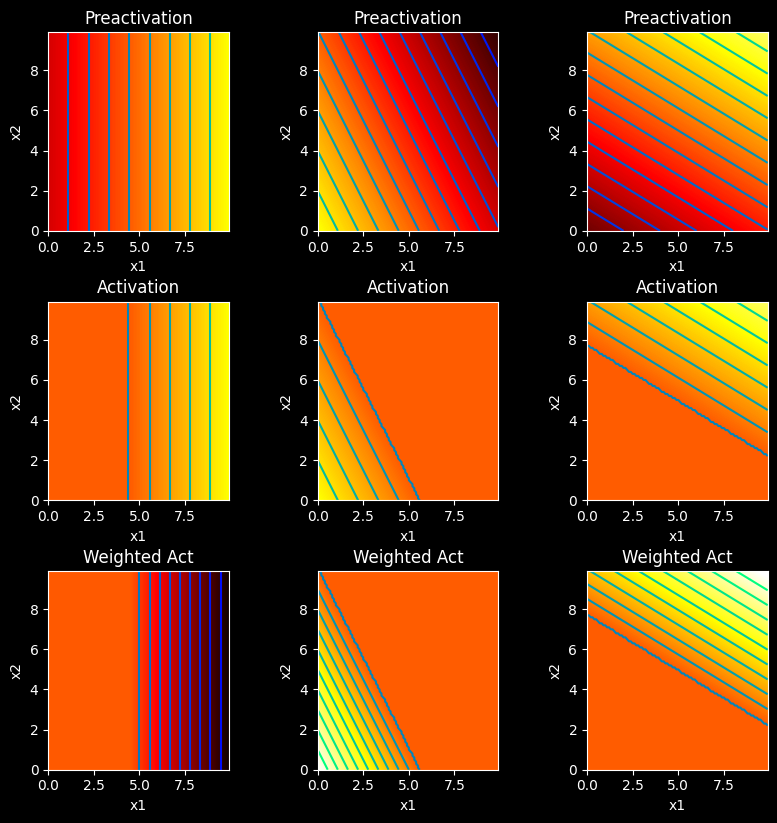

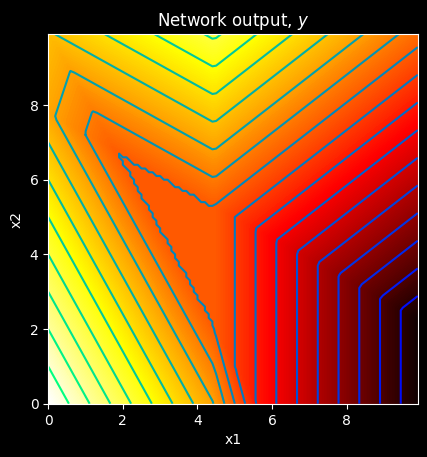

In [35]:
# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_0 = 0.0; phi_1 = -2.0; phi_2 = 2.0; phi_3 = 1.5

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# We run the neural network for each of these input values
y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_2_1_3(x1,x2, ReLU, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# And then plot it
plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3)


In [36]:
# Cada combinação (a1, a2, a3) onde a_i = 0 ou a_i > 0 define uma região
polytope_regions = {}

x1_flat = x1.flatten()
x2_flat = x2.flatten()
act_1_flat = act_1.flatten()
act_2_flat = act_2.flatten()
act_3_flat = act_3.flatten()
y_flat = y.flatten()

#regiões baseado em qual neurônio está ativo (>0 ou =0)
for i in range(len(x1_flat)):
    # chave para cada região (combinação de ativações)
    key = (int(act_1_flat[i] > 0.01), int(act_2_flat[i] > 0.01), int(act_3_flat[i] > 0.01))

    if key not in polytope_regions:
        polytope_regions[key] = {
            'count': 0,
            'x1_range': [x1_flat[i], x1_flat[i]],
            'x2_range': [x2_flat[i], x2_flat[i]],
            'y_range': [y_flat[i], y_flat[i]]
        }

    polytope_regions[key]['count'] += 1
    polytope_regions[key]['x1_range'][0] = min(polytope_regions[key]['x1_range'][0], x1_flat[i])
    polytope_regions[key]['x1_range'][1] = max(polytope_regions[key]['x1_range'][1], x1_flat[i])
    polytope_regions[key]['x2_range'][0] = min(polytope_regions[key]['x2_range'][0], x2_flat[i])
    polytope_regions[key]['x2_range'][1] = max(polytope_regions[key]['x2_range'][1], x2_flat[i])
    polytope_regions[key]['y_range'][0] = min(polytope_regions[key]['y_range'][0], y_flat[i])
    polytope_regions[key]['y_range'][1] = max(polytope_regions[key]['y_range'][1], y_flat[i])

# ordenarregiões por y_range para melhor visualização
sorted_regions = sorted(polytope_regions.items(), key=lambda x: x[1]['y_range'][0])

print("=" * 80)
print("ANÁLISE DE POLYTOPES LINEARES - Rede Neural Rasa (2-3-1)")
print("=" * 80)
print(f"\nTotal de polytopes lineares identificados: {len(polytope_regions)}\n")

for idx, (key, region) in enumerate(sorted_regions, 1):
    act_1_status, act_2_status, act_3_status = key
    print(f"Polytope {idx}:")
    print(f"  Neurônios ativos: [h1={act_1_status}, h2={act_2_status}, h3={act_3_status}]")
    print(f"  Intervalo x1: [{region['x1_range'][0]:.2f}, {region['x1_range'][1]:.2f}]")
    print(f"  Intervalo x2: [{region['x2_range'][0]:.2f}, {region['x2_range'][1]:.2f}]")
    print(f"  Saída y: [{region['y_range'][0]:.2f}, {region['y_range'][1]:.2f}]")
    print(f"  Pontos nesta região: {region['count']}")
    print()

print("=" * 80)

num_polytopes = len(polytope_regions)


ANÁLISE DE POLYTOPES LINEARES - Rede Neural Rasa (2-3-1)

Total de polytopes lineares identificados: 7

Polytope 1:
  Neurônios ativos: [h1=1, h2=0, h3=0]
  Intervalo x1: [4.50, 9.90]
  Intervalo x2: [0.00, 5.20]
  Saída y: [-9.82, -0.10]
  Pontos nesta região: 1997

Polytope 2:
  Neurônios ativos: [h1=1, h2=0, h3=1]
  Intervalo x1: [4.50, 9.90]
  Intervalo x2: [2.30, 9.90]
  Saída y: [-9.79, 6.14]
  Pontos nesta região: 3391

Polytope 3:
  Neurônios ativos: [h1=1, h2=1, h3=0]
  Intervalo x1: [4.50, 5.50]
  Intervalo x2: [0.00, 1.80]
  Saída y: [-1.80, 1.80]
  Pontos nesta região: 112

Polytope 4:
  Neurônios ativos: [h1=0, h2=0, h3=0]
  Intervalo x1: [1.90, 4.40]
  Intervalo x2: [2.10, 6.70]
  Saída y: [0.00, 0.02]
  Pontos nesta região: 451

Polytope 5:
  Neurônios ativos: [h1=0, h2=0, h3=1]
  Intervalo x1: [0.10, 4.40]
  Intervalo x2: [5.40, 9.90]
  Saída y: [0.02, 6.17]
  Pontos nesta região: 1322

Polytope 6:
  Neurônios ativos: [h1=0, h2=1, h3=0]
  Intervalo x1: [0.00, 4.40]
  In

Quantos polytopos lineares diferentes são feitos por este modelo? Identifique cada um na saída da rede.
7

Agora estenderemos este modelo para ter duas saídas 𝑦1 e 𝑦2 , cada uma das quais pode ser visualizada com um mapa de calor separado. Agora você terá conjuntos de parâmetros $\phi_{10}, \phi_{11}, \phi_{12}, \phi_{13}$ and $\phi_{20}, \phi_{21}, \phi_{22}, \phi_{23}$ que correspondem a cada uma dessas saídas.

In [37]:

# Define a shallow neural network with, two inputs, two outputs, and three hidden units
def shallow_2_2_3(x1,x2, activation_fn, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11,\
                  theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32):

  # Computar as pré-ativações (iguais ao caso anterior)
  pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
  pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
  pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

  # Aplicar função de ativação ReLU
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)

  # Ponderar ativações para primeira saída y1
  w_act_11 = phi_11 * act_1
  w_act_12 = phi_12 * act_2
  w_act_13 = phi_13 * act_3

  # Ponderar ativações para segunda saída y2
  w_act_21 = phi_21 * act_1
  w_act_22 = phi_22 * act_2
  w_act_23 = phi_23 * act_3

  # Calcular as duas saídas
  y1 = phi_10 + w_act_11 + w_act_12 + w_act_13
  y2 = phi_20 + w_act_21 + w_act_22 + w_act_23

  # Return everything we have calculated
  return y1,y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23


In [38]:
# Plot the shallow neural network.  We'll assume input in is range [0,10],[0,10] and output [-10,10]
def plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23):

  # Plot intermediate plots if flag set
  fig, ax = plt.subplots(4,3)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  draw_2D_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2D_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2D_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2D_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2D_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2D_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2D_function(ax[2,0], x1,x2,w_act_11); ax[2,0].set_title('Weighted Act 1')
  draw_2D_function(ax[2,1], x1,x2,w_act_12); ax[2,1].set_title('Weighted Act 1')
  draw_2D_function(ax[2,2], x1,x2,w_act_13); ax[2,2].set_title('Weighted Act 1')
  draw_2D_function(ax[3,0], x1,x2,w_act_21); ax[3,0].set_title('Weighted Act 2')
  draw_2D_function(ax[3,1], x1,x2,w_act_22); ax[3,1].set_title('Weighted Act 2')
  draw_2D_function(ax[3,2], x1,x2,w_act_23); ax[3,2].set_title('Weighted Act 2')
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y1)
  ax.set_title('Network output, $y_1$')
  ax.set_aspect(1.0)
  plt.show()

  fig, ax = plt.subplots()
  draw_2D_function(ax,x1,x2,y2)
  ax.set_title('Network output, $y_2$')
  ax.set_aspect(1.0)
  plt.show()

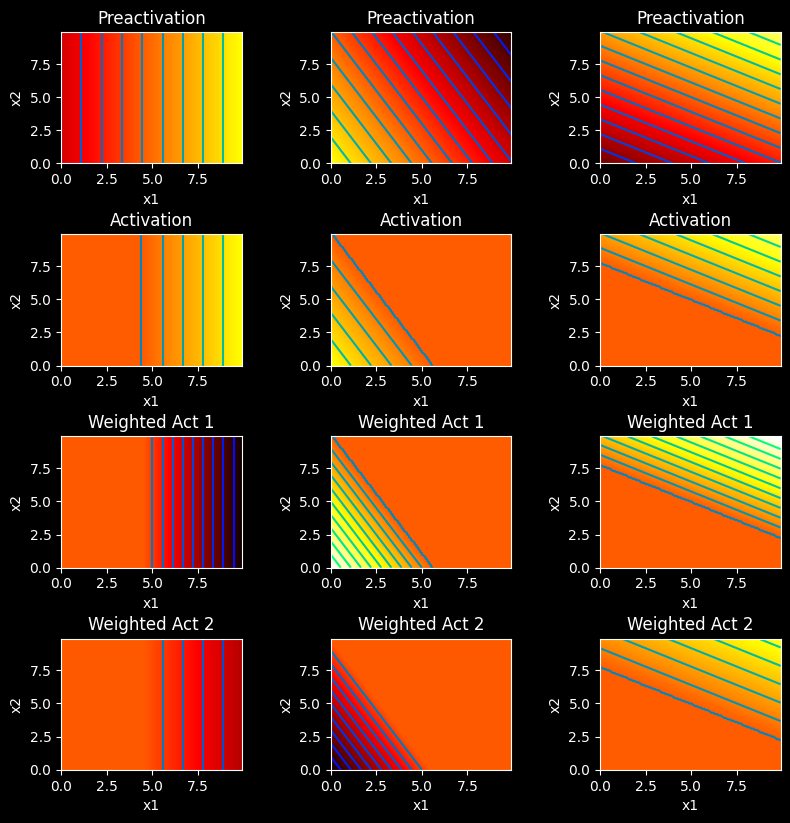

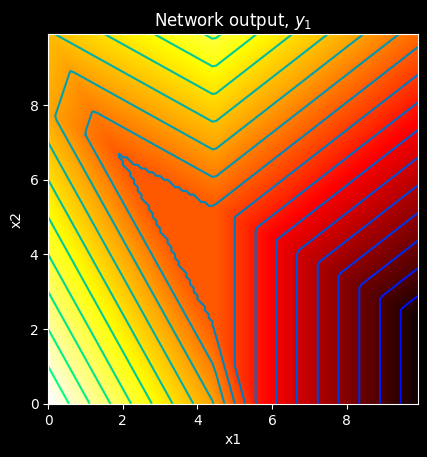

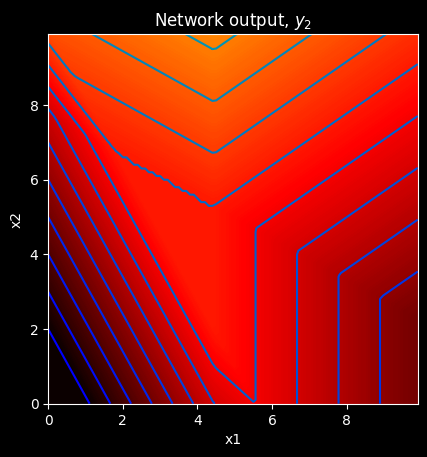

In [39]:

# Now lets define some parameters and run the neural network
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_10 = 0.0; phi_11 = -2.0; phi_12 = 2.0; phi_13 = 1.5
phi_20 = -2.0; phi_21 = -1.0; phi_22 = -2.0; phi_23 = 0.8

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)  # https://www.geeksforgeeks.org/numpy-meshgrid-function/

# We run the neural network for each of these input values
y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23 = \
    shallow_2_2_3(x1,x2, ReLU, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)
# And then plot it
plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23)